In [11]:
import torch
import torch.nn as nn
import numpy as np

class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=0.2)
        self.fc_mu     = nn.Linear(hidden_size, latent_size)
        self.fc_logvar = nn.Linear(hidden_size, latent_size)
    
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)       # h_n: (num_layers, batch, hidden)
        h = h_n[-1]                       # take last layer's hidden state
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class LSTMDecoder(nn.Module):
    def __init__(self, latent_size, hidden_size, output_size, seq_len, num_layers=2):
        super().__init__()
        self.seq_len = seq_len
        self.fc      = nn.Linear(latent_size, hidden_size)
        self.lstm    = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers,
                               batch_first=True, dropout=0.2)
        self.output  = nn.Linear(hidden_size, output_size)
    
    def forward(self, z):
        h = self.fc(z).unsqueeze(1)               # (batch, 1, hidden)
        h = h.repeat(1, self.seq_len, 1)          # (batch, seq_len, hidden)
        out, _ = self.lstm(h)
        return self.output(out)                   # (batch, seq_len, output_size)


class LSTMVAE(nn.Module):
    def __init__(self, input_size, hidden_size=128, latent_size=32, seq_len=50, num_layers=2):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size, latent_size, num_layers)
        self.decoder = LSTMDecoder(latent_size, hidden_size, input_size, seq_len, num_layers)
    
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterise(mu, logvar)
        x_hat      = self.decoder(z)
        return x_hat, mu, logvar


def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    # Reconstruction loss: how well did we rebuild the sequence?
    recon = nn.functional.mse_loss(x_hat, x, reduction="mean")
    # KL divergence: keeps latent space well-structured
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

def train_vae(model, train_sequences, epochs=50, batch_size=64, lr=1e-3, beta_max=1.0, kl_anneal_epochs=20,):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)
    
    X      = torch.tensor(train_sequences, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)
    # Note: shuffle=True is fine HERE because we already made sequences
    # The temporal order is captured within each sequence window

    history = {"train_loss": [], "train_recon": [], "train_kl": [],
               "mu_mean": [], "mu_std": []}
    
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        total_loss = recon_loss = kl_loss = 0
        beta = min(beta_max, beta_max * epoch / kl_anneal_epochs)
        
        for (batch,) in loader:
            batch = batch.to(device)
            optimiser.zero_grad()
            
            x_hat, mu, logvar = model(batch)
            loss, recon, kl   = vae_loss(batch, x_hat, mu, logvar, beta=beta)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            
            total_loss += loss.item()
            recon_loss += recon.item()
            kl_loss    += kl.item()
        
        n = len(loader)
        n_samples = len(loader.dataset)
        avg_loss  = total_loss / n_samples
        avg_recon = recon_loss / n_samples
        avg_kl    = kl_loss / n_samples
        
        # --- Monitor latent variables ---
        mu_mean = mu.mean().item()
        mu_std  = mu.std().item()
        
        history["train_loss"].append(avg_loss)
        history["train_recon"].append(avg_recon)
        history["train_kl"].append(avg_kl)
        history["mu_mean"].append(mu_mean)
        history["mu_std"].append(mu_std)

        print(f"Epoch {epoch+1:3d} | Loss: {total_loss/n_samples:.4f} | Recon: {recon_loss/n_samples:.4f} | KL: {kl_loss/n_samples:.4f} | β={beta:.3f}")
        print(f"          μ mean: {mu_mean:.4f}, μ std: {mu_std:.4f}")

    plt.plot(history["train_loss"], label="Total Loss")
    plt.plot(history["train_recon"], label="Reconstruction")
    plt.plot(history["train_kl"], label="KL")
    plt.legend(); plt.show()
    
    return model

In [12]:
def get_anomaly_scores(model, sequences):
    """Returns per-sequence reconstruction error."""
    model.eval()
    device = next(model.parameters()).device
    
    X      = torch.tensor(sequences, dtype=torch.float32).to(device)
    scores = []
    
    with torch.no_grad():
        for i in range(0, len(X), 256):
            batch         = X[i:i+256]
            x_hat, mu, _ = model(batch)
            # Mean squared error per sequence
            recon_err     = ((batch - x_hat) ** 2).mean(dim=[1, 2])
            scores.extend(recon_err.cpu().numpy())
    
    return np.array(scores)

In [3]:
import polars as pl 

train_df = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\train_sequences_192_168_1_196.parquet")
test_df  = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\test_sequences_192_168_1_196.parquet")

In [4]:
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nTrain columns:", train_df.columns)
print("\nTrain sample:")
print(train_df.head(3))


Train shape: (256144, 2050)
Test shape:  (125352, 2050)

Train columns: ['f0_t0', 'f1_t0', 'f2_t0', 'f3_t0', 'f4_t0', 'f5_t0', 'f6_t0', 'f7_t0', 'f8_t0', 'f9_t0', 'f10_t0', 'f11_t0', 'f12_t0', 'f13_t0', 'f14_t0', 'f15_t0', 'f16_t0', 'f17_t0', 'f18_t0', 'f19_t0', 'f20_t0', 'f21_t0', 'f22_t0', 'f23_t0', 'f24_t0', 'f25_t0', 'f26_t0', 'f27_t0', 'f28_t0', 'f29_t0', 'f30_t0', 'f31_t0', 'f32_t0', 'f33_t0', 'f34_t0', 'f35_t0', 'f36_t0', 'f37_t0', 'f38_t0', 'f39_t0', 'f40_t0', 'f0_t1', 'f1_t1', 'f2_t1', 'f3_t1', 'f4_t1', 'f5_t1', 'f6_t1', 'f7_t1', 'f8_t1', 'f9_t1', 'f10_t1', 'f11_t1', 'f12_t1', 'f13_t1', 'f14_t1', 'f15_t1', 'f16_t1', 'f17_t1', 'f18_t1', 'f19_t1', 'f20_t1', 'f21_t1', 'f22_t1', 'f23_t1', 'f24_t1', 'f25_t1', 'f26_t1', 'f27_t1', 'f28_t1', 'f29_t1', 'f30_t1', 'f31_t1', 'f32_t1', 'f33_t1', 'f34_t1', 'f35_t1', 'f36_t1', 'f37_t1', 'f38_t1', 'f39_t1', 'f40_t1', 'f0_t2', 'f1_t2', 'f2_t2', 'f3_t2', 'f4_t2', 'f5_t2', 'f6_t2', 'f7_t2', 'f8_t2', 'f9_t2', 'f10_t2', 'f11_t2', 'f12_t2', 'f13_t2

In [7]:
import numpy as np

N_FEATURES  = 41   # f0 to f40
WINDOW_SIZE = 50   # t0 to t49
N_COLS      = N_FEATURES * WINDOW_SIZE  # should be 2050

print(f"Columns: {train_df.shape[1]} (expected {N_COLS})")

train_np = train_df.to_numpy().astype(np.float32)
test_np  = test_df.to_numpy().astype(np.float32)

train_seq = train_np.reshape(-1, WINDOW_SIZE, N_FEATURES)
test_seq  = test_np.reshape(-1, WINDOW_SIZE, N_FEATURES)

print(f"Train sequences shape: {train_seq.shape}")  # (256144, 50, 41)
print(f"Test sequences shape:  {test_seq.shape}")   # (125352, 50, 41)

# ── Sanity check — no NaNs or Infs ────────────────────────────────
print(f"Train NaN: {np.isnan(train_seq).sum()}")
print(f"Train Inf: {np.isinf(train_seq).sum()}")

Columns: 2050 (expected 2050)
Train sequences shape: (256144, 50, 41)
Test sequences shape:  (125352, 50, 41)
Train NaN: 0
Train Inf: 0


c:\Users\babai\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Model parameters: 892,585
Epoch   1 | Loss: 0.0107 | Recon: 0.0107 | KL: 0.0510 | β=0.000
          μ mean: -0.0342, μ std: 1.1316
Epoch   2 | Loss: 0.0107 | Recon: 0.0106 | KL: 0.0017 | β=0.050
          μ mean: 0.0054, μ std: 0.2102
Epoch   3 | Loss: 0.0106 | Recon: 0.0105 | KL: 0.0012 | β=0.100
          μ mean: 0.0157, μ std: 0.2682
Epoch   4 | Loss: 0.0105 | Recon: 0.0103 | KL: 0.0011 | β=0.150
          μ mean: -0.0032, μ std: 0.2547
Epoch   5 | Loss: 0.0103 | Recon: 0.0101 | KL: 0.0011 | β=0.200
          μ mean: 0.0046, μ std: 0.1950
Epoch   6 | Loss: 0.0101 | Recon: 0.0098 | KL: 0.0010 | β=0.250
          μ mean: -0.0010, μ std: 0.1866
Epoch   7 | Loss: 0.0098 | Recon: 0.0095 | KL: 0.0011 | β=0.300
          μ mean: -0.0071, μ std: 0.2559
Epoch   8 | Loss: 0.0098 | Recon: 0.0095 | KL: 0.0010 | β=0.350
          μ mean: -0.0092, μ std: 0.2701
Epoch   9 | Loss: 0.0097 | Recon: 0.0093 | KL: 0.0009 | β=0.400
          μ mean: 0.0000, μ std: 0.1915
Epoch  10 | Loss: 0.0096 | Recon:

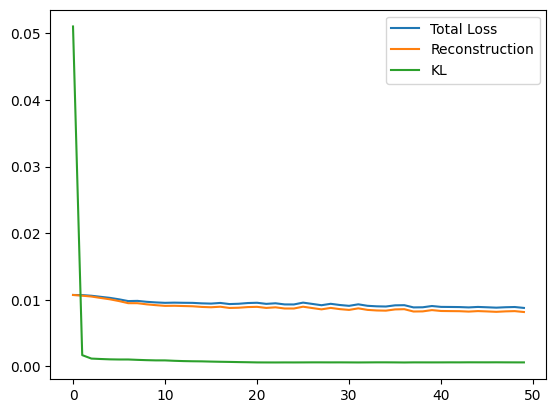

Model saved → C:\Users\babai\OneDrive\Desktop\CaseStudiesDatasets\models\model_lstm_vae_v2_192_168_1_196_lstm_vae.pt


In [25]:
model = LSTMVAE(
    input_size  = N_FEATURES,   # 41
    hidden_size = 256,
    latent_size = 64,
    seq_len     = WINDOW_SIZE,  # 50
    num_layers  = 1
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

# ── Train ──────────────────────────────────────────────────────────
model = train_vae(
    model            = model,
    train_sequences  = train_seq,
    epochs           = 50,
    batch_size       = 64,
    lr               = 1e-3,
    beta_max         = 1.0,
    kl_anneal_epochs = 20
)

model_path = f"C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\models\\model_lstm_vae_v2_192_168_1_196_lstm_vae.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "input_size":  N_FEATURES,
        "hidden_size": 128,
        "latent_size": 32,
        "seq_len":     WINDOW_SIZE,
        "num_layers":  2,
    },
    "ts_min": 1545402842.863612,
}, model_path)
print(f"Model saved → {model_path}")

In [17]:
import polars as pl
test_raw_df  = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\traintestdata\\test_192_168_100_103.parquet")
train_raw_df  = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\traintestdata\\train_192_168_100_103.parquet")

In [18]:
print(test_raw_df.columns)
print(train_raw_df.columns)

['ts', 'id.orig_h', 'id.orig_p', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'history', 'orig_pkts', 'resp_pkts', 'label', 'detailed-label']
['ts', 'id.orig_h', 'id.orig_p', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'history', 'orig_pkts', 'resp_pkts', 'label', 'detailed-label']


In [5]:
import numpy as np
test_seq_labels = []
test_raw_labels = (test_raw_df["detailed-label"] != "-").to_numpy().astype(int)
WINDOW_SIZE = 50
STEP_SIZE = 25

test_seq_labels = []
for start in range(0, len(test_raw_labels) - WINDOW_SIZE, STEP_SIZE):
    window_labels = test_raw_labels[start : start + WINDOW_SIZE]
    test_seq_labels.append(int(window_labels.any()))  # 1 if any malicious in window

test_seq_labels = np.array(test_seq_labels)

print(f"Test sequences — Benign: {(test_seq_labels==0).sum():,} | "
      f"Malicious: {(test_seq_labels==1).sum():,}")

Test sequences — Benign: 121 | Malicious: 11,809


In [19]:
import numpy as np
train_seq_labels = []
test_raw_labels = (train_raw_df["detailed-label"] != "-").to_numpy().astype(int)
WINDOW_SIZE = 50
STEP_SIZE = 25

train_seq_labels = []
for start in range(0, len(test_raw_labels) - WINDOW_SIZE, STEP_SIZE):
    window_labels = test_raw_labels[start : start + WINDOW_SIZE]
    train_seq_labels.append(int(window_labels.any()))  # 1 if any malicious in window

train_seq_labels = np.array(train_seq_labels)

print(f"Test sequences — Benign: {(train_seq_labels==0).sum():,} | "
      f"Malicious: {(train_seq_labels==1).sum():,}")

Test sequences — Benign: 12,446 | Malicious: 0


In [20]:
new_test_df  = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\test_sequences_192_168_100_103.parquet")
new_train_df = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\train_sequences_192_168_100_103.parquet")
import numpy as np

N_FEATURES  = 41   # f0 to f40
WINDOW_SIZE = 50   # t0 to t49
N_COLS      = N_FEATURES * WINDOW_SIZE  # should be 2050

print(f"Columns: {new_train_df.shape[1]} (expected {N_COLS})")

new_train_np = new_train_df.to_numpy().astype(np.float32)
new_test_np  = new_test_df.to_numpy().astype(np.float32)

new_train_seq = new_train_np.reshape(-1, WINDOW_SIZE, N_FEATURES)
new_test_seq  = new_test_np.reshape(-1, WINDOW_SIZE, N_FEATURES)

print(f"Train sequences shape: {new_train_seq.shape}")  # (256144, 50, 41)
print(f"Test sequences shape:  {new_test_seq.shape}")   # (125352, 50, 41)

# ── Sanity check — no NaNs or Infs ────────────────────────────────
print(f"Train NaN: {np.isnan(new_train_seq).sum()}")
print(f"Train Inf: {np.isinf(new_train_seq).sum()}")

Columns: 2050 (expected 2050)
Train sequences shape: (12446, 50, 41)
Test sequences shape:  (11930, 50, 41)
Train NaN: 0
Train Inf: 0


In [23]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(DEVICE)
# model.eval()
recon_scores = []
test_model_path = "C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\models\\model_lstm_vae_v1_192_168_1_196_lstm_vae.pt"
checkpoint = torch.load(test_model_path, map_location=DEVICE)

config = checkpoint["config"]

model = LSTMVAE(
    input_size=config["input_size"],
    hidden_size=config["hidden_size"],
    latent_size=config["latent_size"],
    seq_len=config["seq_len"],
    num_layers=config["num_layers"],
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_loader  = DataLoader(new_test_seq,  batch_size=256, shuffle=False,
                          num_workers=0)

with torch.no_grad():
    for (batch) in test_loader:
        batch         = batch.to(DEVICE)
        x_hat, mu, _ = model(batch)
        # Per-sequence reconstruction error
        err = ((batch - x_hat) ** 2).mean(dim=[1, 2])
        recon_scores.extend(err.cpu().numpy())

recon_scores = np.array(recon_scores)

# ── ROC-AUC ────────────────────────────────────────────────────────────────
auc = roc_auc_score(test_seq_labels, recon_scores)
print(f"\nROC-AUC: {auc:.4f}")

# ── Find best threshold ────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds = precision_recall_curve(test_seq_labels, recon_scores)
f1_scores  = 2 * precision * recall / (precision + recall + 1e-8)
best_idx   = f1_scores.argmax()
best_thresh = thresholds[best_idx]

print(f"Best threshold: {best_thresh:.4f}")
print(f"Best F1:        {f1_scores[best_idx]:.4f}")

predictions = (recon_scores > best_thresh).astype(int)
print("\nClassification Report:")
print(classification_report(test_seq_labels, predictions,
                             target_names=["Benign", "Malicious"]))


C:\Users\babai\AppData\Local\Temp\ipykernel_3672\1135326222.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(test_model_path, map_location=DEVICE


ROC-AUC: 0.0004
Best threshold: 0.8985
Best F1:        0.9949

Classification Report:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       121
   Malicious       0.99      1.00      0.99     11809

    accuracy                           0.99     11930
   macro avg       0.49      0.50      0.50     11930
weighted avg       0.98      0.99      0.98     11930

